Department: Human Resources, Attrition Count: 12
{'_id': 'Human Resources', 'attritionCount': 12}
Department: Sales, Attrition Count: 92
{'_id': 'Sales', 'attritionCount': 92}
Department: Research & Development, Attrition Count: 133
{'_id': 'Research & Development', 'attritionCount': 133}


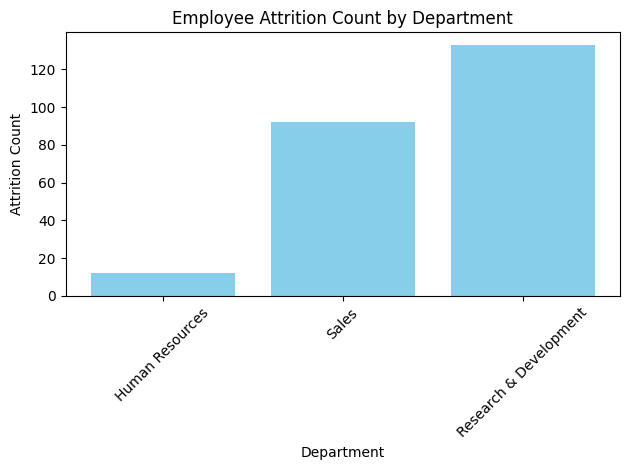

: 

In [18]:
import matplotlib.pyplot as plt
from pymongo import MongoClient
connection_string = 'mongodb://localhost:27017/'
client = MongoClient(connection_string)
db = client['work_attrition']
collection = db['attrition']
pipeline = [
    { "$match": { "Attrition": "Yes" } },
    { "$group": { "_id": "$Department", "attritionCount": { "$sum": 1 } } }
]
departments = []
attrition_counts = []

results = collection.aggregate(pipeline)
for result in results:
    print(f"Department: {result['_id']}, Attrition Count: {result['attritionCount']}")
    departments.append(result['_id'])
    attrition_counts.append(result['attritionCount'])


# Create a bar chart
plt.bar(departments, attrition_counts, color='skyblue')
plt.xlabel('Department')
plt.ylabel('Attrition Count')
plt.title('Employee Attrition Count by Department')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [8]:
print(results)

In [2]:
pip install pymongo

  Using cached dnspython-2.7.0-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/926.7 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/926.7 kB ? eta -:--:--
   ---------------------------------------- 926.7/926.7 kB 3.9 MB/s eta 0:00:00
Using cached dnspython-2.7.0-py3-none-any.whl (313 kB)
Note: you may need to restart the kernel to use updated packages.
